# **Métodos ensemble**


Profesor: **D.Sc. Pastor Enmanuel Pérez Estigarribia**

**CONTENIDO**

1.   Métodos voting, bagging, boosting, stacking.
2.   Aplicación de métodos ensemble con Python.

**OBJETIVOS:**


**Conceptuales**

Entender el funcionamiento de los métodos ensemble.

**Procedimentales:**

Aplicar métodos ensemble empleando Python.

**Actitudinales:**

Aprovechar las capacidades de Python para aplicar métodos ensemble.

# **Bagging Ensemble con Python**

El embolsado es un algoritmo de aprendizaje automático conjunto que combina las predicciones de muchos árboles de decisión.

<img src='https://machinelearningmastery.com/wp-content/uploads/2020/11/Bagging-Ensemble.png'>

Fuente: https://machinelearningmastery.com/tour-of-ensemble-learning-algorithms/

<img src='https://miro.medium.com/v2/resize:fit:828/0*PBGJw23ud8Sp7qO4.'>

Fuente: https://towardsdatascience.com/ensemble-methods-in-machine-learning-what-are-they-and-why-use-them-68ec3f9fef5f


## [**Bagging Scikit-Learn API**](https://machinelearningmastery.com/bagging-ensemble-with-python/)

Puede ver [Cómo implementar el embolsado desde cero con Python aqui](https://machinelearningmastery.com/implement-bagging-scratch-python/).



In [ ]:
# evaluate bagging algorithm for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier

import sklearn
print(sklearn.__version__)

1.2.2


El embolsado se proporciona a través de las clases BaggingRegressor y BaggingClassifier .


### **Bagging para Clasificación**

Primero, podemos usar la función make_classification() para crear un problema de clasificación binaria sintética con 1000 ejemplos y 20 características de entrada.

In [ ]:
# test classification dataset
from sklearn.datasets import make_classification
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=5)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


Evaluaremos el modelo usando validación cruzada de k-fold estratificado repetido , con tres repeticiones y 10 fold. Informaremos la media y la desviación estándar de la precisión del modelo en todas las repeticiones y fold.

<img src='https://scikit-learn.org/stable/_images/grid_search_cross_validation.png'>

Fuente: https://scikit-learn.org/stable/modules/cross_validation.html

In [ ]:

# evaluate bagging algorithm for classification
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=5)
# define the model
model = BaggingClassifier()
# evaluate the model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

Accuracy: 0.864 (0.044)


Primero, el conjunto Bagging se ajusta a todos los datos disponibles, luego se puede llamar a la función predict() para hacer predicciones sobre nuevos datos.El siguiente ejemplo demuestra esto en nuestro conjunto de datos de clasificación binaria.

In [ ]:
# make predictions using bagging for classification
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier
# define dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=5)
# define the model
model = BaggingClassifier()
# fit the model on the whole dataset
model.fit(X, y)
# make a single prediction
row = [[-4.7705504,-1.88685058,-0.96057964,2.53850317,-6.5843005,3.45711663,-7.46225013,2.01338213,-0.45086384,-1.89314931,-2.90675203,-0.21214568,-0.9623956,3.93862591,0.06276375,0.33964269,4.0835676,1.31423977,-2.17983117,3.1047287]]
yhat = model.predict(row)
print('Predicted Class: %d' % yhat[0])

Predicted Class: 1


### **Bagging for Regression**

Primero, podemos usar la función make_regression() para crear un problema de regresión sintética con 1000 ejemplos y 20 características de entrada.

In [ ]:
# test regression dataset
from sklearn.datasets import make_regression
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=5)
# summarize the dataset
print(X.shape, y.shape)

(1000, 20) (1000,)


Como hicimos en el caso anterior, evaluaremos el modelo usando validación cruzada repetida de k-fold, con tres repeticiones y 10 fold. Informaremos el error absoluto medio (MAE) del modelo en todas las repeticiones y pliegues. La biblioteca scikit-learn hace que el MAE sea negativo para que se maximice en lugar de minimizarse. Esto significa que los MAE negativos más grandes son mejores y un modelo perfecto tiene un MAE de 0.

<img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/3ef87b78a9af65e308cf4aa9acf6f203efbdeded'>



In [ ]:
# evaluate bagging ensemble for regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import BaggingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=5)
# define the model
model = BaggingRegressor()
# evaluate the model
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('MAE: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

MAE: -101.315 (10.268)


Primero, el conjunto Bagging se ajusta a todos los datos disponibles, luego se puede llamar a la función predict() para hacer predicciones sobre nuevos datos.

In [ ]:
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor
# define dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=15, noise=0.1, random_state=5)
# define the model
model = BaggingRegressor()
# fit the model on the whole dataset
model.fit(X, y)
# make a single prediction
row = [[0.88950817,-0.93540416,0.08392824,0.26438806,-0.52828711,-1.21102238,-0.4499934,1.47392391,-0.19737726,-0.22252503,0.02307668,0.26953276,0.03572757,-0.51606983,-0.39937452,1.8121736,-0.00775917,-0.02514283,-0.76089365,1.58692212]]
yhat = model.predict(row)
print('Prediction: %d' % yhat[0])

Prediction: -167


### **Bagging Hyperparameters**

Analizaremos más de cerca algunos de los hiperparámetros que debe considerar ajustar para el conjunto Bagging y su efecto en el rendimiento del modelo.

#### **Explorar número de árboles**

Por lo general, la cantidad de árboles aumenta hasta que el rendimiento del modelo se estabiliza. La intuición podría sugerir que más árboles conducirán a un sobreajuste, aunque este no es el caso. El embolsado y el conjunto relacionado de algoritmos de árboles de decisión (como RF) parecen ser algo inmunes al sobreajuste del conjunto de datos de entrenamiento dada la naturaleza estocástica del algoritmo de aprendizaje.

El siguiente ejemplo explora el efecto del número de árboles con valores entre 10 y 5000.

>10 0.861 (0.041)
>50 0.876 (0.035)
>100 0.885 (0.035)
>500 0.884 (0.036)
>1000 0.887 (0.037)
>5000 0.885 (0.038)


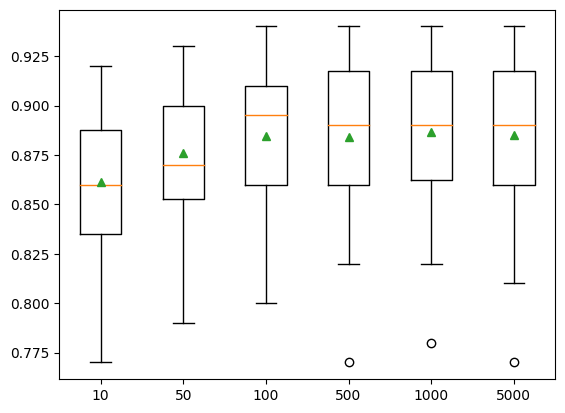

In [ ]:

# explore bagging ensemble number of trees effect on performance
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=5)
 return X, y

# get a list of models to evaluate
def get_models():
 models = dict()
 # define number of trees to consider
 #  n_trees = [10, 50, 100, 500, 500, 1000, 5000]
 n_trees = [10, 50, 100, 500, 1000]
 for n in n_trees:
  models[str(n)] = BaggingClassifier(n_estimators=n)
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 # define the evaluation procedure
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # evaluate the model and collect the results
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 # evaluate the model
 scores = evaluate_model(model, X, y)
 # store the results
 results.append(scores)
 names.append(name)
 # summarize the performance along the way
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

#### **Explorar número de muestras**

El tamaño de la muestra de bootstrap también se puede variar.

El valor predeterminado es crear una muestra de bootstrap que tenga la misma cantidad de ejemplos que el conjunto de datos original. El uso de un conjunto de datos más pequeño puede aumentar la varianza de los árboles de decisión resultantes y podría generar un mejor rendimiento general.

El número de muestras utilizadas para adaptarse a cada árbol de decisión se establece mediante el argumento "max_samples".

El siguiente ejemplo explora muestras de diferentes tamaños como una proporción del conjunto de datos original del 10 al 100 por ciento (el valor predeterminado).

>0.1 0.811 (0.043)
>0.2 0.825 (0.036)
>0.3 0.842 (0.037)
>0.4 0.846 (0.034)
>0.5 0.854 (0.043)
>0.6 0.851 (0.042)
>0.7 0.855 (0.037)
>0.8 0.866 (0.037)
>0.9 0.858 (0.037)
>1.0 0.860 (0.043)


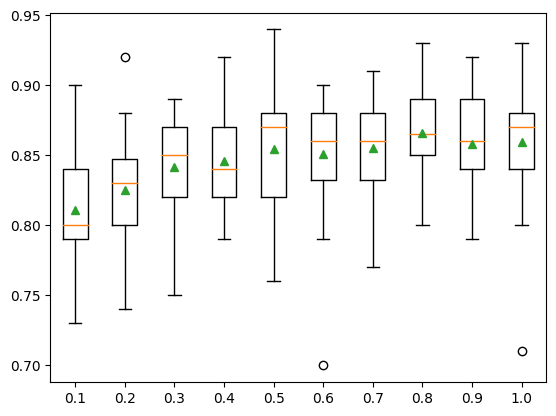

In [ ]:

# explore bagging ensemble number of samples effect on performance
from numpy import mean
from numpy import std
from numpy import arange
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=5)
 return X, y

# get a list of models to evaluate
def get_models():
 models = dict()
 # explore ratios from 10% to 100% in 10% increments
 for i in arange(0.1, 1.1, 0.1):
  key = '%.1f' % i
  models[key] = BaggingClassifier(max_samples=i)
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 # define the evaluation procedure
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # evaluate the model and collect the results
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 # evaluate the model
 scores = evaluate_model(model, X, y)
 # store the results
 results.append(scores)
 names.append(name)
 # summarize the performance along the way
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

#### **Explorar algoritmo alternativo**

Se pueden usar otros algoritmos con bagging y deben configurarse para tener una varianza moderadamente alta. Un ejemplo es el algoritmo de k vecinos más cercanos , donde el valor k se puede establecer en un valor bajo.

El siguiente ejemplo demuestra el uso de KNeighborsClassifier como algoritmo base utilizado en el conjunto de embolsado. Aquí, el algoritmo se usa con hiperparámetros predeterminados donde k se establece en 5.

>1 0.884 (0.030)
>2 0.881 (0.032)
>3 0.885 (0.035)
>4 0.886 (0.031)
>5 0.885 (0.037)
>6 0.883 (0.036)
>7 0.875 (0.038)
>8 0.881 (0.037)
>9 0.875 (0.035)
>10 0.875 (0.032)
>11 0.877 (0.033)
>12 0.875 (0.038)
>13 0.874 (0.036)
>14 0.872 (0.028)
>15 0.875 (0.033)
>16 0.878 (0.035)
>17 0.878 (0.038)
>18 0.874 (0.032)
>19 0.871 (0.034)
>20 0.877 (0.032)


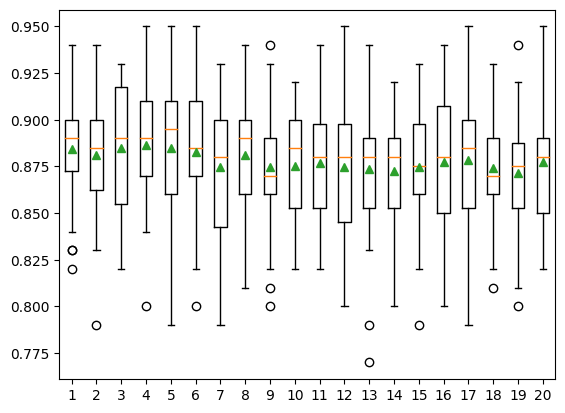

In [ ]:
# explore bagging ensemble k for knn effect on performance
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot

# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=5)
 return X, y

# get a list of models to evaluate
def get_models():
 models = dict()
 # evaluate k values from 1 to 20
 for i in range(1,21):
 # define the base model
  base = KNeighborsClassifier(n_neighbors=i)
 # define the ensemble model
  models[str(i)] = BaggingClassifier(base_estimator=base)
 return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
 # define the evaluation procedure
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # evaluate the model and collect the results
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
 return scores

# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
 # evaluate the model
 scores = evaluate_model(model, X, y)
 # store the results
 results.append(scores)
 names.append(name)
 # summarize the performance along the way
 print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()